In [1]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.ensemble import ObliqueRandomForestRegressor
import xgboost as xgb

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


1000
(1000, 57) (1000,)
1000 train done
1.7028453080243258


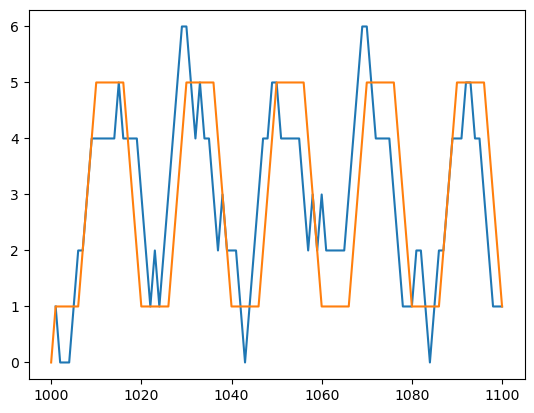

5000
(5000, 57) (5000,)
5000 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_88351/1923601374.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.302674308681819


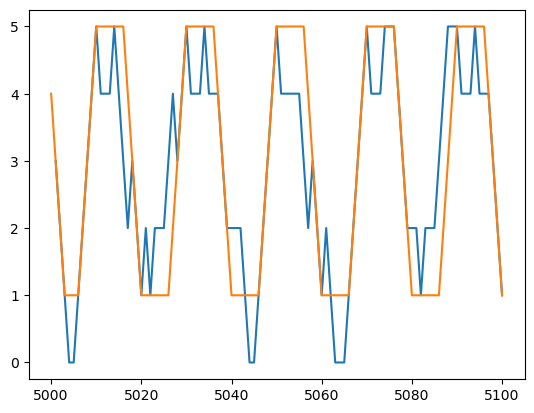

10000
(10000, 57) (10000,)
10000 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_88351/1923601374.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.9638087075428428


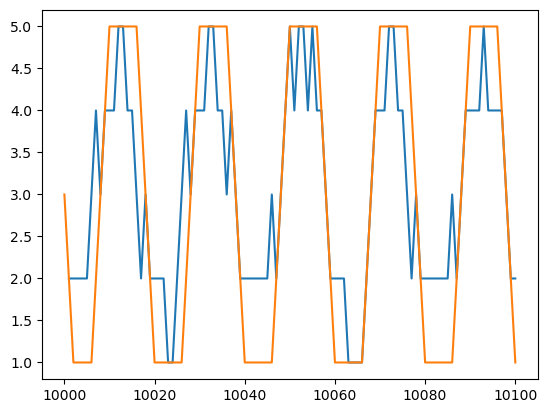

20000
(20000, 57) (20000,)
20000 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_88351/1923601374.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.6683342138051196


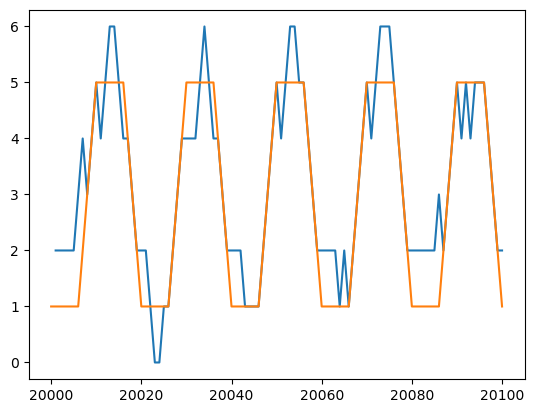

40000
(40000, 57) (40000,)
40000 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_88351/1923601374.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.6663957851275664


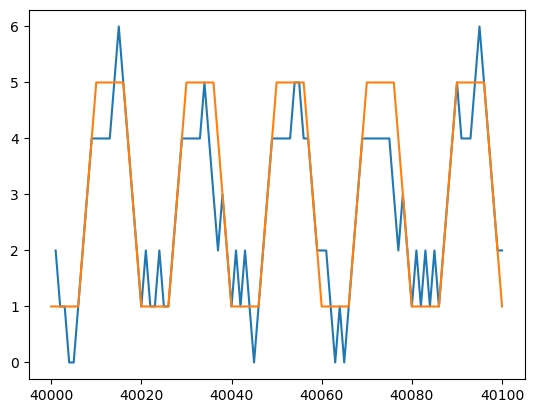

80000
(80000, 57) (80000,)
80000 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_88351/1923601374.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.3667604670821571


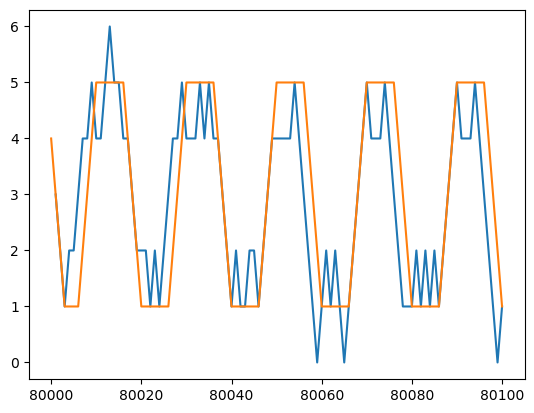

In [9]:
DELTA_t = 10
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
FUTURE_STATE = []
for T in Ts:
    # n_seq = int(T/(DELTA_t+1))
    n_seq = T
    print(n_seq)
    state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
    time_raw = np.random.choice([int(i) for i in range(T-DELTA_t)],size = n_seq)
    opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
    STATES = []
    for i in range(len(time_raw)):
        path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
        # print(state_raw[i],path)
        times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
        opt_paths.append(path)
        opt_irewards.append(rewards)
        opt_times.append(times)
        opt_prewards.append(preward_opt(rewards[1:],gamma = 0.5))
        state_posencode_oh = position_encoder(np.array(path), type="onehot")
        time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
        # print(time_emb.shape,state_posencode_oh.shape)
        state_pe = np.hstack([state_posencode_oh,time_emb])
        STATES.append(state_pe[0,:])
    STATES_arr = np.vstack(STATES)
    REWARDS_arr = np.hstack(np.array(opt_prewards).reshape(-1,1))
    print(STATES_arr.shape,REWARDS_arr.shape)
    # plt.plot(opt_times[0],opt_paths[0])
    # plt.show()
    # plt.plot(opt_times[0],opt_irewards[0])
    # plt.show()
    X_train = STATES_arr
    Y_train = REWARDS_arr
    rf = RandomForestRegressor(n_estimators=1000, random_state=9515)
    ## Using XGB regressor with delta = 1 is converging faster -- 150
    # rf = xgb.XGBRegressor(
    #     objective="reg:squarederror",
    #     tree_method="exact",     # or "exact" (slower, RAM heavy)
    #     n_jobs = -1,
    #     learning_rate=0.05, max_depth=5,
    #     subsample=1, colsample_bytree=0.8,
    #     n_estimators=1000, eval_metric="rmse"
    # )
    rf.fit(X_train, Y_train)
    print(T,'train done')

    
    current_state = np.random.choice([int(i) for i in range(7)],size = 1)
    future_states = [current_state.item()]
    # print(current_state)
    for delta_t in range(100):
        df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
        n_paths = df_all_paths.shape[0]
        irewards_pred = np.zeros((n_paths,  t_prime+1))
        for i in range(t_prime+1):
            cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
            curr_time = T+1+delta_t+i
            time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
            features = np.hstack([cand_pe,time_emb])
            irewards_pred[:,i] = rf.predict(features)
        reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
        df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
        # Extract rewards from second column onward (t=1 to t=T)
        rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
        discounts = gamma ** np.arange(1, t_prime+1)

        # Compute discounted total reward per path
        discounted_returns = rewards_matrix * discounts  
        total_discounted = discounted_returns.sum(axis=1)
        # print(total_discounted)
        bext_idx = np.argmax(total_discounted)
        next_state = int(df_all_paths.iloc[bext_idx,1])
        # print(df_all_paths.iloc[bext_idx,:])
        future_states.append(next_state)
        current_state = next_state
    
    # print(T,future_states,len(future_states))
    FUTURE_STATE.append(future_states)

    irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    preward = compute_normalized_future_rewards(irewards,100,0.5)
    path, ireward_opt = path_opt(future_states[0], T, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
    pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
    print(pregret)
    plt.plot(np.arange(T+1,T+101),future_states[1:])
    plt.plot(np.arange(T,T+101),path)
    plt.show()

FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
np.savez(
    f"../results/PVFM/RF_optimal_oh_w_time1000_80000_lookahead{t_prime}_reps{0}.npz",
    future_states =FUTURE_STATE_arr
    )

